正在读取 PulseParameter.txt 并计算理论位置...
正在启动自动检测流程 (FFT粗筛 & TEO)...


Overall Progress: 100%|█████████▉| 4211040/4211378 [00:00<00:00, 15908042.94it/s]


正在生成对比图... 理论脉冲数: 113, 自动检测数: 119


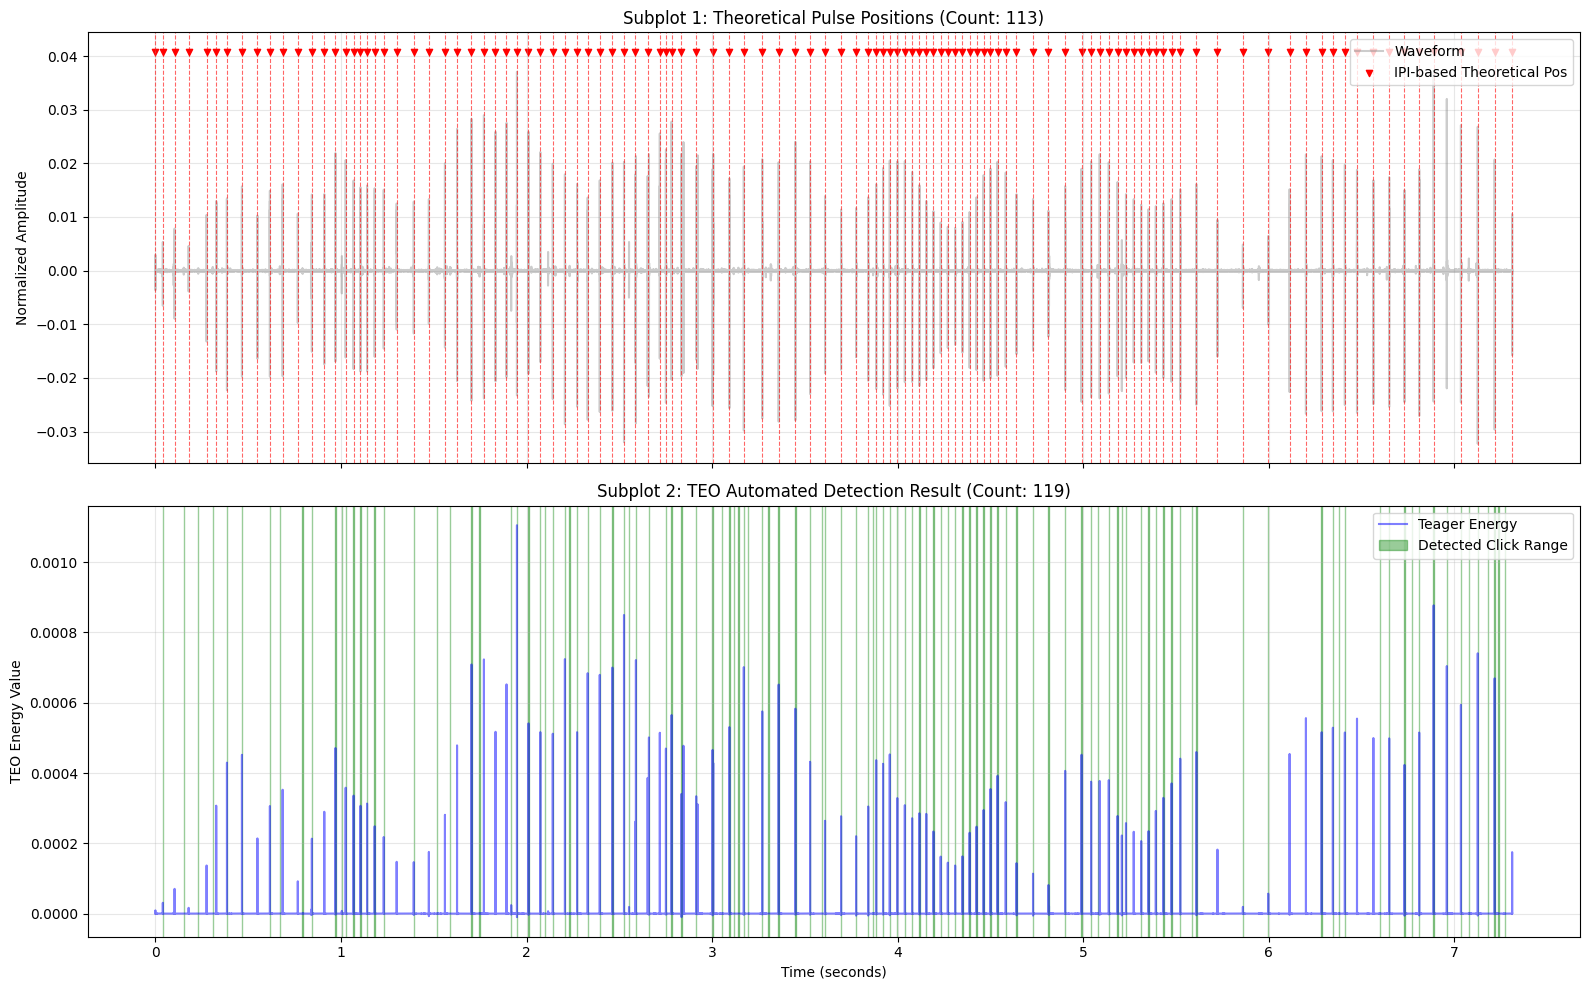

In [7]:
import os
import numpy as np
import scipy.io.wavfile as wav
from scipy.signal import windows
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

# 路径定义（绝对路径）
BASE_DIR = r'D:\Project_Github\Indo-Pacific-humpback-dolphin\00_Data\ClickTrains\PulseTrain_020'
TRAIN_PATH = os.path.join(BASE_DIR, 'PulseTrain.wav')
PARAM_PATH = os.path.join(BASE_DIR, 'PulseParameters.txt')

def teager_energy_operator(sig):
    """计算Teager能量算子: TEO(x[n]) = x[n]^2 - x[n-1]x[n+1]"""
    res = np.zeros_like(sig)
    # 向量化计算提高效率
    res[1:-1] = sig[1:-1]**2 - sig[:-2] * sig[2:]
    return res

def moving_average(a, n=10):
    """滑动平均"""
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

def process_analysis():
    # 1. 加载音频数据
    if not os.path.exists(TRAIN_PATH):
        print(f"错误：找不到音频文件 {TRAIN_PATH}")
        return
    fs, train_data = wav.read(TRAIN_PATH)
    if train_data.dtype != np.float32:
        train_data = train_data.astype(np.float32) / np.iinfo(train_data.dtype).max
    
    duration_sec = len(train_data) / fs
    time_axis = np.arange(len(train_data)) / fs

    # --- 阶段一：解析 IPI 数据计算理论位置 ---
    print("正在读取 PulseParameter.txt 并计算理论位置...")
    # 使用 r'\s+' 修正 SyntaxWarning
    try:
        df_param = pd.read_csv(PARAM_PATH, sep=r'\s+')
    except Exception as e:
        print(f"解析文本文件失败: {e}")
        return

    # 计算脉冲时间点 (单位: 秒)
    ipi_ms = df_param['IPI(ms)'].fillna(0).values
    theoretical_times = [0.0]
    current_time = 0.0
    for i in range(len(ipi_ms) - 1):
        current_time += ipi_ms[i] / 1000.0  # ms 转 s
        theoretical_times.append(current_time)
    
    theoretical_times = np.array(theoretical_times)

    # --- 阶段二：自动化信号检测 (FFT粗筛 + TEO精定位) ---
    print("正在启动自动检测流程 (FFT粗筛 & TEO)...")
    
    fft_size = 512 
    hop_size = fft_size // 2
    win = windows.hann(fft_size)
    freqs = np.fft.rfftfreq(fft_size, 1/fs)
    idx_band = np.where((freqs >= 15000) & (freqs <= 95000))[0]
    
    teo_val = teager_energy_operator(train_data)
    noise_baseline = np.percentile(teo_val, 40)
    core_threshold = noise_baseline * 100
    
    detected_clicks = []
    total_samples = len(train_data)
    
    # 总体进度条
    pbar = tqdm(total=total_samples, desc="Overall Progress")

    i = 0
    while i < total_samples - fft_size:
        segment = train_data[i:i+fft_size]
        spec = np.abs(np.fft.rfft(segment * win))
        mean_spec = np.mean(spec)
        db_spec = 20 * np.log10(spec / (mean_spec + 1e-6))
        
        if np.sum(db_spec[idx_band] > 13) > (len(idx_band) * 0.125):
            buffer_samples = int(0.0075 * fs)
            start_search = max(0, i - buffer_samples)
            end_search = min(total_samples, i + fft_size + buffer_samples)
            
            search_teo = teo_val[start_search:end_search]
            core_indices = np.where(search_teo > core_threshold)[0]
            
            if len(core_indices) > 0:
                peak_idx_local = core_indices[np.argmax(search_teo[core_indices])]
                peak_idx_global = start_search + peak_idx_local
                
                refine_range = 500
                r_start = max(0, peak_idx_global - refine_range)
                r_end = min(total_samples, peak_idx_global + refine_range)
                
                ma_teo = moving_average(teo_val[r_start:r_end], 10)
                active_bins = np.where(ma_teo > (noise_baseline * 3))[0]
                
                if len(active_bins) > 0:
                    start_p = r_start + active_bins[0]
                    end_p = r_start + active_bins[-1]
                    
                    is_redundant = False
                    for existing in detected_clicks:
                        if abs(existing['peak'] - peak_idx_global) < int(0.015 * fs):
                            if search_teo[peak_idx_local] > existing['val']:
                                detected_clicks.remove(existing)
                            else:
                                is_redundant = True
                            break
                    
                    if not is_redundant:
                        detected_clicks.append({
                            'start': start_p,
                            'end': end_p,
                            'peak': peak_idx_global,
                            'val': search_teo[peak_idx_local]
                        })
            
            i += buffer_samples
            pbar.update(buffer_samples)
        else:
            i += hop_size
            pbar.update(hop_size)
            
    pbar.close()

    # --- 绘图对比 ---
    print(f"正在生成对比图... 理论脉冲数: {len(theoretical_times)}, 自动检测数: {len(detected_clicks)}")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

    # 子图1: 基于 IPI 的理论标注
    ax1.plot(time_axis, train_data, color='gray', alpha=0.4, label='Waveform')
    for t in theoretical_times:
        ax1.axvline(x=t, color='red', linestyle='--', alpha=0.6, linewidth=0.8)
    ax1.scatter(theoretical_times, [np.max(train_data)*1.1]*len(theoretical_times), 
               color='red', marker='v', s=20, label='IPI-based Theoretical Pos')
    ax1.set_title(f'Subplot 1: Theoretical Pulse Positions (Count: {len(theoretical_times)})')
    ax1.set_ylabel('Normalized Amplitude')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # 子图2: TEO 自动检测标注
    ax2.plot(time_axis, teo_val, color='blue', alpha=0.5, label='Teager Energy')
    for click in detected_clicks:
        ax2.axvspan(click['start']/fs, click['end']/fs, color='green', alpha=0.4)
    
    ax2.set_title(f'Subplot 2: TEO Automated Detection Result (Count: {len(detected_clicks)})')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('TEO Energy Value')
    ax2.legend(['Teager Energy', 'Detected Click Range'], loc='upper right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    process_analysis()